# 1. Импорт библтотек

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno
from scipy import stats
import statsmodels.stats.power as smp
import datetime as dt

# 2. Загрузка данных

In [2]:
hits = pd.read_csv('data/hits.csv')
sessions = pd.read_csv('data/sessions.csv')

In [3]:
print(f"Данные загружены. События: {hits.shape}, сессии: {sessions.shape}")

Данные загружены. События: (15726470, 11), сессии: (1860042, 18)


In [4]:
hits.head(3)

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,NaN
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN,NaN
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN,NaN


In [5]:
sessions.head(3)

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk


Данные были загружены из двух источников: таблица с событиями (hits) и таблица с визитами (sessions). Таблица hits содержит информацию о каждом действии пользователя на сайте, а sessions — данные о самом визите. Далее мы проведем их очистку и объединение.

# 3. Разведочный анализ данных (EDA) для таблицы hits

### 3.1. Общая информация о данных

In [6]:
hits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   session_id      object 
 1   hit_date        object 
 2   hit_time        float64
 3   hit_number      int64  
 4   hit_type        object 
 5   hit_referer     object 
 6   hit_page_path   object 
 7   event_category  object 
 8   event_action    object 
 9   event_label     object 
 10  event_value     float64
dtypes: float64(2), int64(1), object(8)
memory usage: 1.3+ GB


### 3.2. Анализ пропущенных значений

In [7]:
print("\nПРОЦЕНТ ПРОПУСКОВ В КАЖДОЙ КОЛОНКЕ\n")
missing_percent = (hits.isnull().sum() / len(hits) * 100).sort_values(ascending=False)
print(missing_percent)


ПРОЦЕНТ ПРОПУСКОВ В КАЖДОЙ КОЛОНКЕ

event_value       100.000000
hit_time           58.247795
hit_referer        39.899634
event_label        23.909905
session_id          0.000000
hit_date            0.000000
hit_number          0.000000
hit_type            0.000000
hit_page_path       0.000000
event_category      0.000000
event_action        0.000000
dtype: float64


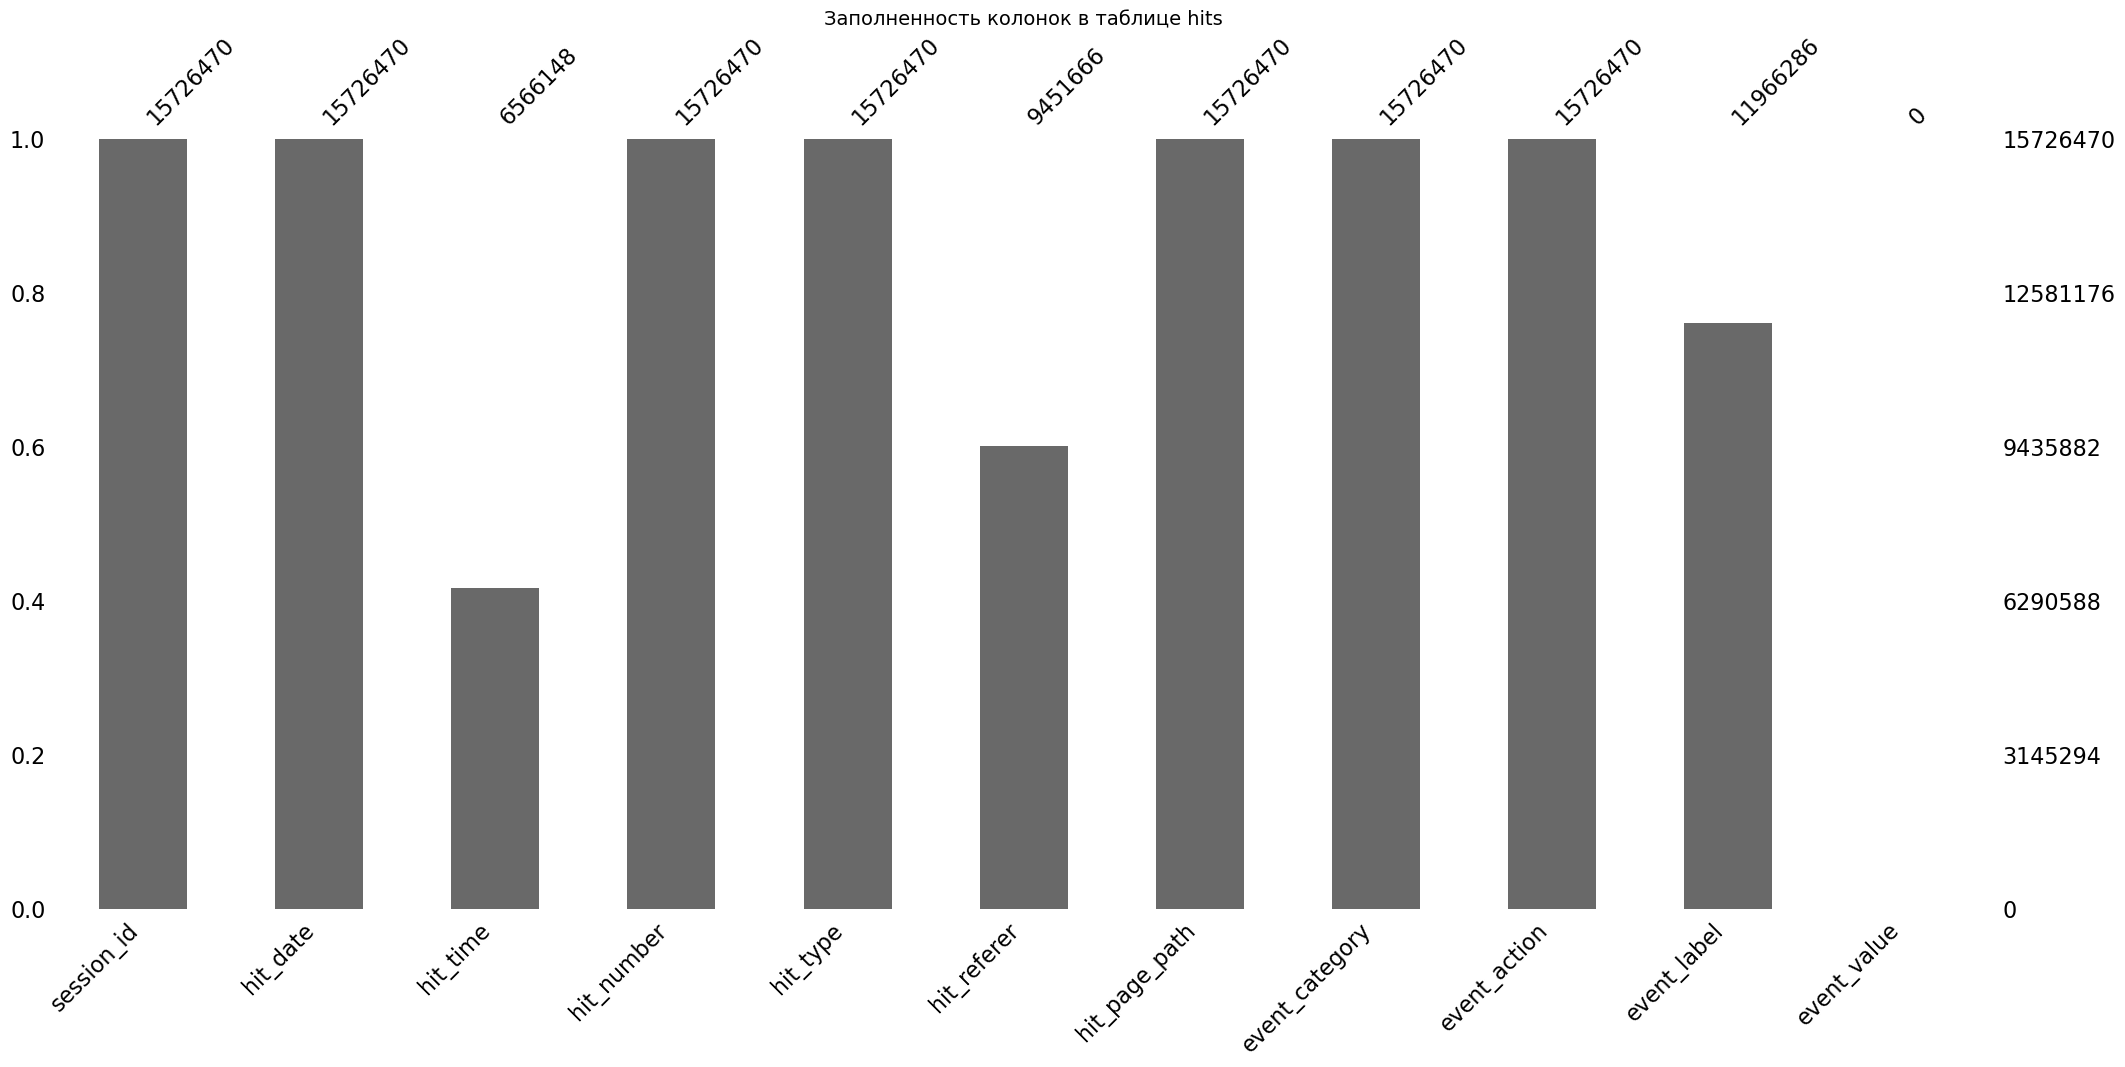

In [8]:
# Визуализация пропусков
plt.figure(figsize=(12, 6))
msno.bar(hits)
plt.title('Заполненность колонок в таблице hits', fontsize=14)
plt.show()

### 3.3. Анализ уникальных значений

In [9]:
print("\nУНИКАЛЬНЫЕ ЗНАЧЕНИЯ В КОЛОНКАХ\n")
for col in hits.columns:
    n_unique = hits[col].nunique()
    sample = hits[col].dropna().unique()[:3]
    print(f"""
Колонка: {col}
Уникальных значений: {n_unique}
Пример:\n{sample}\n""")


УНИКАЛЬНЫЕ ЗНАЧЕНИЯ В КОЛОНКАХ


Колонка: session_id
Уникальных значений: 1734610
Пример:
['5639623078712724064.1640254056.1640254056'
 '7750352294969115059.1640271109.1640271109'
 '885342191847998240.1640235807.1640235807']


Колонка: hit_date
Уникальных значений: 226
Пример:
['2021-12-23' '2021-12-12' '2021-11-17']


Колонка: hit_time
Уникальных значений: 925887
Пример:
[597864. 597331. 796252.]


Колонка: hit_number
Уникальных значений: 500
Пример:
[30 41 49]


Колонка: hit_type
Уникальных значений: 1
Пример:
['event']


Колонка: hit_referer
Уникальных значений: 37873
Пример:
['VloVXNWduHeTjUoDkjkO' 'trXmoxcphNjuYcShOXwL' 'uMnMdxLOIznakHyXLoMC']


Колонка: hit_page_path
Уникальных значений: 342715
Пример:
['sberauto.com/cars?utm_source_initial=google&utm_medium_initial=cpc&utm_campaign_initial=bJJuEXRheRIxXEaYIXqM|BmWKiKCvBVipoWOpNUIL&utm_content_initial=yXzSAJWSuRbYeLFyMVFl|iJxXDTgPAXGQYOdgCzqe|xAEYTlJDbQNwQTLGxICQ|pmvTbUlmnwAkuHIbvKUg|lFpAoUqEvHoyZfCNRuCR|oxjYxrkwnRSTTYcVZzdb|dtY

### 3.4. Проверка дубликатов

In [10]:
print(f"\nПРОВЕРКА ДУБЛИКАТОВ\n")
print(f"Всего строк: {len(hits)}")
print(f"Полных дубликатов: {hits.duplicated().sum()}")
print(f"Процент дубликатов: {hits.duplicated().sum() / len(hits) * 100:.2f}%")


ПРОВЕРКА ДУБЛИКАТОВ

Всего строк: 15726470
Полных дубликатов: 0
Процент дубликатов: 0.00%


### 3.5. Удаление неинформативных колонок

In [11]:
hits_columns_to_drop = [
    'hit_time',        # 58% пропусков, не связано с бизнес-задачами
    'hit_number',      # порядковый номер в рамках сессии — не влияет на конверсию
    'hit_type',        # всего 1 уникальное значение - "event"
    'hit_referer',     # 40% пропусков, много уникальных значений без пояснений
    'event_category',  # не связано с целевыми действиями
    'event_label',     # 24% пропусков, много уникальных значений без пояснений
    'event_value'      # 100% пропусков
]

hits = hits.drop(columns = hits_columns_to_drop)

### 3.6. Создание целевого признака

In [12]:
target_actions = [
    'sub_car_claim_click', 'sub_car_claim_submit_click',
    'sub_open_dialog_click', 'sub_custom_question_submit_click',
    'sub_call_number_click', 'sub_callback_submit_click',
    'sub_submit_success', 'sub_car_request_submit_click'
]

hits['target_action'] = hits['event_action'].apply(
    lambda x: 1 if x in target_actions else 0
)

### 3.7. Извлечение производителя и модели из URL

In [13]:
hits['manufacturer'] = hits['hit_page_path'].apply(
    lambda x: x.split('cars/all/')[-1].split('/')[0] if 'cars/all/' in x else '-'
)

In [14]:
hits['car_model'] = hits['hit_page_path'].apply(\
    lambda x: (x.split('cars/all/')[-1].split('/')[0] + ' ' + x.split('cars/all/')[-1].split('/')[1])\
        if 'cars/all/' in x else '-'
)

### 3.8.Преобразование даты

In [15]:
hits['hit_date'] = pd.to_datetime(hits['hit_date'])

### 3.9. Удаление отработанных колонок

In [16]:
hits = hits.drop(columns=['hit_page_path', 'event_action'])

In [17]:
hits.head(10)

,session_id,hit_date,target_action,manufacturer,car_model
0,5639623078712724064.1640254056.1640254056,2021-12-23,0,-,-
1,7750352294969115059.1640271109.1640271109,2021-12-23,0,-,-
2,885342191847998240.1640235807.1640235807,2021-12-23,0,volkswagen,volkswagen polo
3,142526202120934167.1640211014.1640211014,2021-12-23,0,-,-
4,3450086108837475701.1640265078.1640265078,2021-12-23,0,mercedes-benz,mercedes-benz cla-klasse
5,6466333295973247896.1640246168.1640246168,2021-12-23,0,-,-
6,281215510786615563.1640245516.1640245516,2021-12-23,0,-,-
7,4024492994895054107.1640269084.1640269084,2021-12-23,0,mercedes-benz,mercedes-benz glc
8,555009234841130092.1640256620.1640256620,2021-12-23,0,kia,kia sorento
9,2692901778487480807.1640206845.1640206845,2021-12-23,0,nissan,nissan x-trail


### 3.10. Агрегация hits по сессиям

In [18]:
hits_agg = hits.groupby('session_id', as_index=False).agg({
    'hit_date': 'first',
    'manufacturer': 'max',
    'car_model': 'max',
    'target_action': 'max'
})

print(f"Уникальных сессий в hits: {len(hits_agg)}")

Уникальных сессий в hits: 1734610


In [19]:
hits_agg.head()

,session_id,hit_date,manufacturer,car_model,target_action
0,1000009318903347362.1632663668.1632663668,2021-09-26,-,-,0
1,1000010177899156286.1635013443.1635013443,2021-10-23,-,-,0
2,1000013386240115915.1635402956.1635402956,2021-10-28,lada-vaz,lada-vaz vesta,0
3,1000017303238376207.1623489300.1623489300,2021-06-12,-,-,0
4,1000020580299877109.1624943350.1624943350,2021-06-29,-,-,0


## 4. Разведочный анализ данных (EDA) для таблицы sessions

### 4.1. Общая информация о данных

In [20]:
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 18 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   session_id                object
 1   client_id                 object
 2   visit_date                object
 3   visit_time                object
 4   visit_number              int64 
 5   utm_source                object
 6   utm_medium                object
 7   utm_campaign              object
 8   utm_adcontent             object
 9   utm_keyword               object
 10  device_category           object
 11  device_os                 object
 12  device_brand              object
 13  device_model              object
 14  device_screen_resolution  object
 15  device_browser            object
 16  geo_country               object
 17  geo_city                  object
dtypes: int64(1), object(17)
memory usage: 255.4+ MB


### 4.2. Анализ пропущенных значений

In [21]:
print("\nПРОЦЕНТ ПРОПУСКОВ В КАЖДОЙ КОЛОНКЕ\n")
missing_percent = (sessions.isnull().sum() / len(sessions) * 100).sort_values(ascending=False)
print(missing_percent)


ПРОЦЕНТ ПРОПУСКОВ В КАЖДОЙ КОЛОНКЕ

device_model                99.121633
utm_keyword                 58.174009
device_os                   57.533002
device_brand                19.740307
utm_adcontent               18.043410
utm_campaign                11.806346
utm_source                   0.005215
geo_country                  0.000000
device_browser               0.000000
device_screen_resolution     0.000000
session_id                   0.000000
device_category              0.000000
client_id                    0.000000
utm_medium                   0.000000
visit_number                 0.000000
visit_time                   0.000000
visit_date                   0.000000
geo_city                     0.000000
dtype: float64


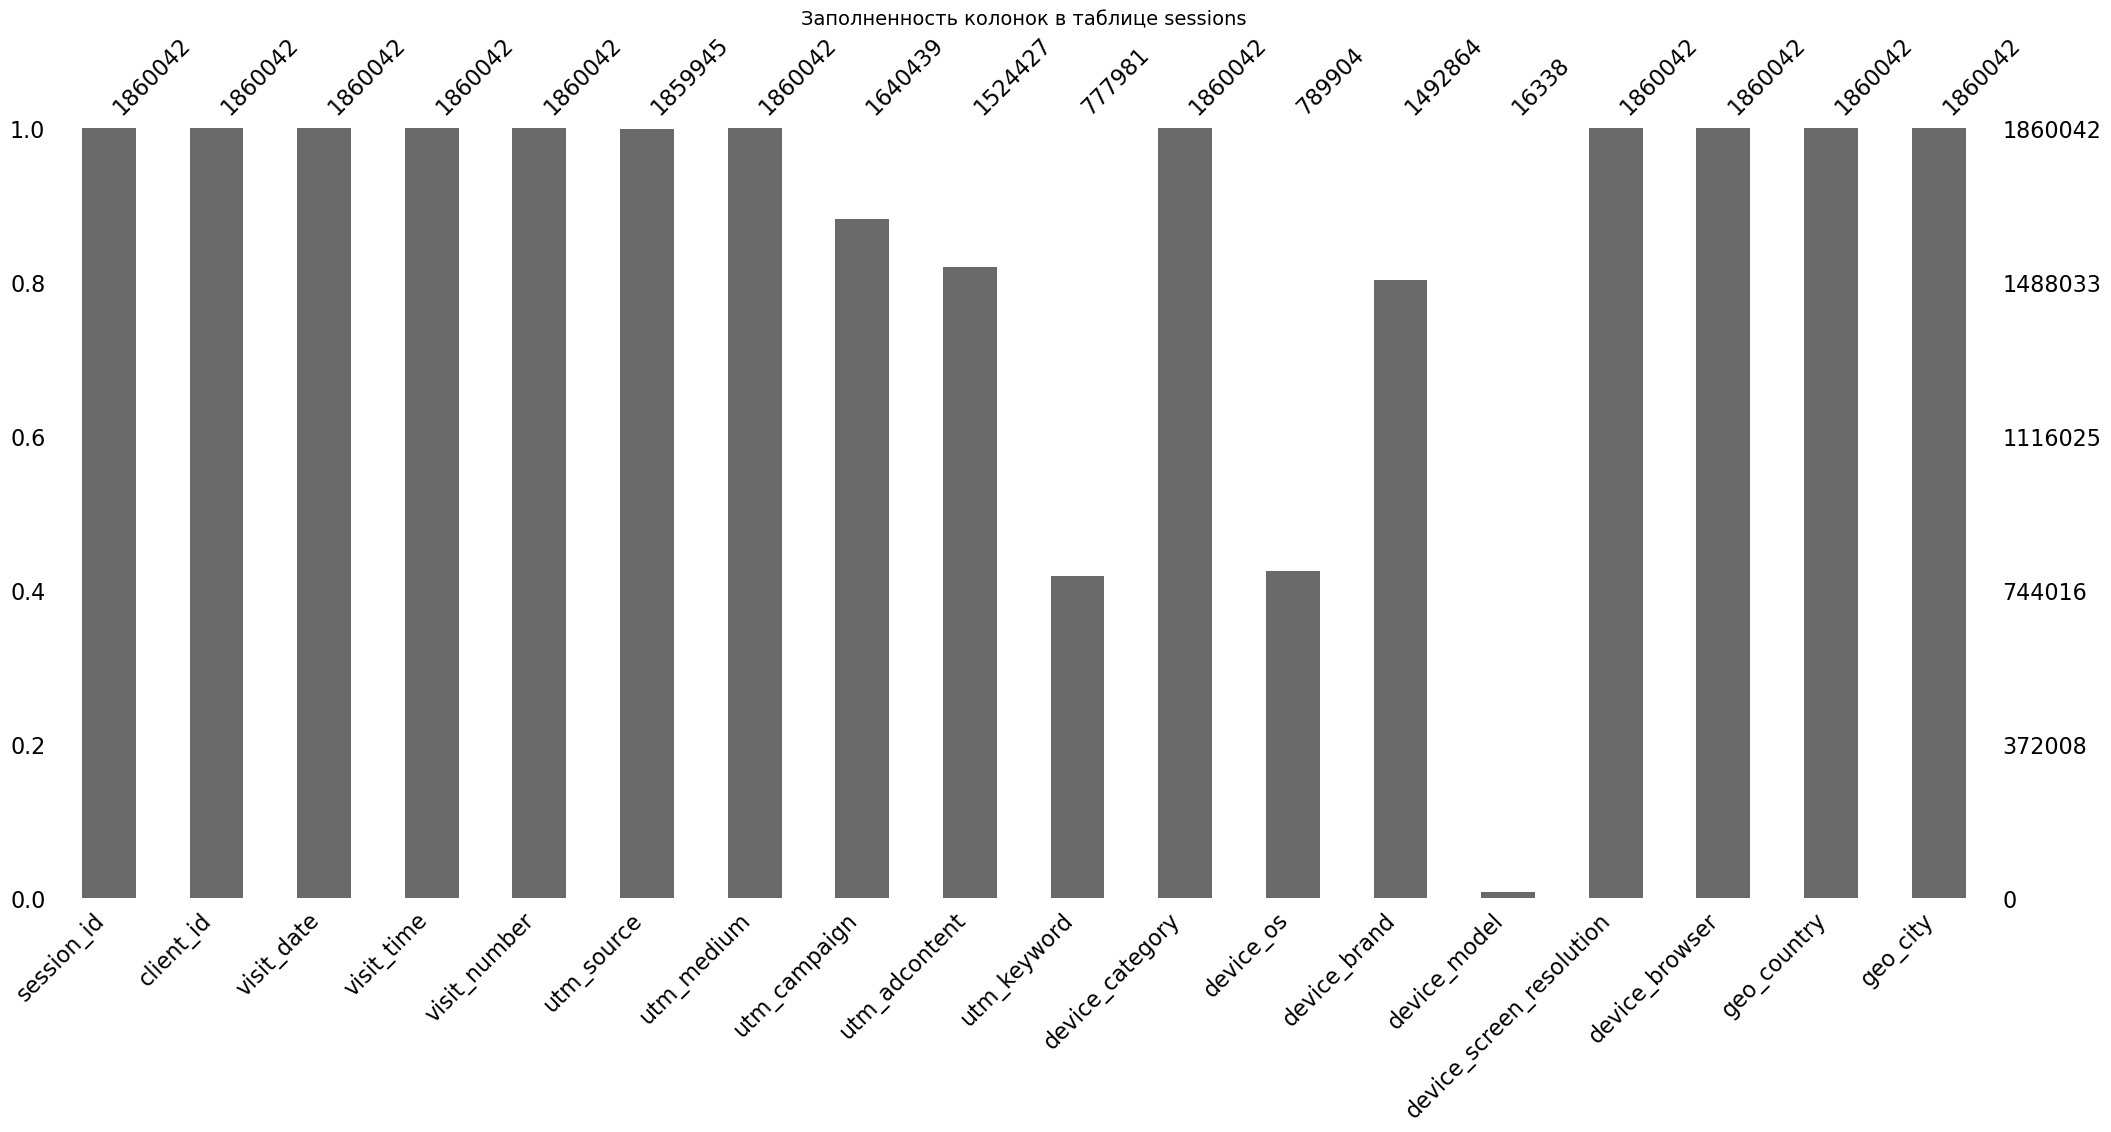

In [22]:
# Визуализация пропусков
plt.figure(figsize=(12, 6))
msno.bar(sessions)
plt.title('Заполненность колонок в таблице sessions', fontsize=14)
plt.show()

### 4.3. Анализ уникальных значений

In [23]:
print("\nУНИКАЛЬНЫЕ ЗНАЧЕНИЯ В КОЛОНКАХ\n")
for col in sessions.columns:
    n_unique = sessions[col].nunique()
    sample = sessions[col].dropna().unique()[:3]
    print(f"""
Колонка: {col}
Уникальных значений: {n_unique}
Пример:\n{sample}\n""")


УНИКАЛЬНЫЕ ЗНАЧЕНИЯ В КОЛОНКАХ


Колонка: session_id
Уникальных значений: 1860042
Пример:
['9055434745589932991.1637753792.1637753792'
 '905544597018549464.1636867290.1636867290'
 '9055446045651783499.1640648526.1640648526']


Колонка: client_id
Уникальных значений: 1391717
Пример:
[2108382700.1637757 210838531.16368672 2108385331.164065]


Колонка: visit_date
Уникальных значений: 226
Пример:
['2021-11-24' '2021-11-14' '2021-12-28']


Колонка: visit_time
Уникальных значений: 85318
Пример:
['14:36:32' '08:21:30' '02:42:06']


Колонка: visit_number
Уникальных значений: 537
Пример:
[1 2 3]


Колонка: utm_source
Уникальных значений: 293
Пример:
['ZpYIoDJMcFzVoPFsHGJL' 'MvfHsxITijuriZxsqZqt' 'kjsLglQLzykiRbcDiGcD']


Колонка: utm_medium
Уникальных значений: 56
Пример:
['banner' 'cpm' 'cpc']


Колонка: utm_campaign
Уникальных значений: 412
Пример:
['LEoPHuyFvzoNfnzGgfcd' 'FTjNLDyTrXaWYgZymFkV' 'LTuZkdKfxRGVceoWkVyg']


Колонка: utm_adcontent
Уникальных значений: 286
Пример:
['vCIpmpaGBnIQhy

### 4.4. Проверка дубликатов

In [24]:
print(f"\nПРОВЕРКА ДУБЛИКАТОВ\n")
print(f"Всего строк: {len(sessions)}")
print(f"Полных дубликатов: {sessions.duplicated().sum()}")
print(f"Процент дубликатов: {sessions.duplicated().sum() / len(sessions) * 100:.2f}%")


ПРОВЕРКА ДУБЛИКАТОВ

Всего строк: 1860042
Полных дубликатов: 0
Процент дубликатов: 0.00%


### 4.5. Принятие решения об удалении колонок

In [25]:
sessions_columns_to_drop = [
    'visit_time',           # не связано с бизнес-задачами
    'visit_number',         # не влияет на конверсию
    'utm_keyword',          # 58% пропусков, много уникальных значений без пояснений
    'device_os',            # 57% пропусков, не связано с бизнес-задачами
    'device_model',         # 99.8% пропусков, много уникальных значений без пояснений
    'utm_adcontent',        # специфические значения без пояснений
    'utm_campaign',         # специфические значения без пояснений
    'device_screen_resolution'  # не связано с конверсией
]

sessions = sessions.drop(columns=sessions_columns_to_drop)
print(f"Удалено {len(sessions_columns_to_drop)} колонок. Новый размер: {sessions.shape}")

Удалено 8 колонок. Новый размер: (1860042, 10)


### 4.6. Замена пропусков

In [26]:
sessions['utm_source'] = sessions['utm_source'].fillna('other')
sessions['device_brand'] = sessions['device_brand'].replace(['None', None], 'other')
sessions['device_brand'] = sessions['device_brand'].fillna('other')

### 4.7. Преобразование даты

In [27]:
sessions['visit_date'] = pd.to_datetime(sessions['visit_date'])

# 5. Загрузка и обработка данных о регионах

### 5.1. Загрузка справочника из Википедии

In [28]:
# Википедия блокирует автоматические запросы, которые не выглядят как запросы от обычного браузера
# Кроме того, есть риск обновления данных на странице, запрет к доступу и пр.
# Выгрузим данные в Excel и достанем их как из файла

cities_df = pd.read_excel('data/list_of_cities_and_towns_in_russia.xlsx')
cities_df.head()

,City,Russian name,Federal subject
0,Abakan,Абакан,Republic of Khakassia
1,Abaza,Абаза,Republic of Khakassia
2,Abdulino,Абдулино,Orenburg Oblast
3,Abinsk,Абинск,Krasnodar Krai
4,Achinsk,Ачинск,Krasnoyarsk Krai


In [29]:
print(f"Загружено {len(cities_df)} городов")

Загружено 1115 городов


### 5.2. Обработка городов-тезок

In [30]:
# Изменим структуру для удобства
cities_df = cities_df[['Federal subject', 'City']]
cities_df.columns = ['region', 'geo_city']
cities_df.head()

,region,geo_city
0,Republic of Khakassia,Abakan
1,Republic of Khakassia,Abaza
2,Orenburg Oblast,Abdulino
3,Krasnodar Krai,Abinsk
4,Krasnoyarsk Krai,Achinsk


In [31]:
cities_df[cities_df.geo_city.duplicated()].reset_index().iloc[:, [1,2]]

,region,geo_city
0,Sverdlovsk Oblast,Berezovsky
1,Republic of Bashkortostan,Blagoveshchensk
2,Primorsky Krai,Fokino
3,Kemerovo Oblast,Guryevsk
4,Kirov Oblast,Kirov
5,Murmansk Oblast,Kirovsk
6,Saratov Oblast,Krasnoarmeysk
7,Republic of Mordovia,Krasnoslobodsk
8,Moscow Oblast,Krasnoznamensk
9,Stavropol Krai,Mikhaylovsk


In [32]:
# удалим тезок, чтобы избежать путанницы:
city_duplicates = cities_df[cities_df['geo_city'].duplicated()]['geo_city'].tolist()
cities_df = cities_df[~cities_df['geo_city'].isin(city_duplicates)]

print(f"Загружено {len(cities_df)} городов")

Загружено 1074 городов


### 5.3. Объединение с основными данными

In [33]:
sessions = sessions.merge(cities_df, on='geo_city', how='left')
sessions['region'] = sessions['region'].fillna('other')

# 5. Feature Engineering и создание новых признаков

In [34]:
# 1. Признак "город присутствия"
presence_cities = ['Moscow', 'Saint Petersburg', 'Moscow Oblast']
sessions['city_of_presence'] = sessions['region'].apply(
    lambda x: 1 if x in presence_cities else 0
)

In [35]:
# 2. Признак "локация" (регион - для РФ, страна - для других)
sessions['location'] = sessions.apply(
    lambda x: x['region'] if x['geo_country'] == 'Russia' else x['geo_country'],
    axis=1
)

In [36]:
# 3. Признак "тип трафика" (органический = 1, платный = 0)
organic = ['organic', 'referral', '(none)']
sessions['traffic'] = sessions['utm_medium'].apply(
    lambda x: 1 if x in organic else 0
)

sessions = sessions.drop(columns=['utm_medium'])

In [37]:
# 4. Признак "тип устройства" (мобильное = 1, десктопное = 0)
sessions['device_category'] = sessions['device_category'].apply(
    lambda x: 1 if x != 'desktop' else 0
)

In [38]:
# 5. Признак "реклама в соцсетях"
social_media = [
    'QxAxdyPLuQMEcrdZWdWb', 'MvfHsxITijuriZxsqZqt',
    'ISrKoXQCxqqYvAZICvjs', 'IZEXUFLARCUMynmHNBGo',
    'PlbkrSYoHuZBWfYjYnfw', 'gVRrcxiDQubJiljoTbGm'
]
sessions['ad_in_social_media'] = sessions['utm_source'].apply(
    lambda x: 1 if x in social_media else 0
)

sessions = sessions.drop(columns=['utm_source'])

In [39]:
# 6. Очистка названий браузеров
sessions['device_browser'] = sessions['device_browser'].str.lower()

sessions['device_browser'] = sessions['device_browser'].apply(
    lambda x: 'instagram' if 'instagram' in x else x
)

sessions['device_browser'] = sessions['device_browser'].apply(
    lambda x: 'safari' if 'safari' in x else x
)

sessions['device_browser'] = sessions['device_browser'].apply(
    lambda x: 'opera' if 'opera' in x else x
)

sessions['device_browser'] = sessions['device_browser'].apply(
    lambda x: 'mozilla_firefox' if ('firefox' in x or 'mozilla' in x) else x
)

In [40]:
sessions.head()

,session_id,client_id,visit_date,device_category,device_brand,device_browser,geo_country,geo_city,region,city_of_presence,location,traffic,ad_in_social_media
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,1,Huawei,chrome,Russia,Zlatoust,Chelyabinsk Oblast,0,Chelyabinsk Oblast,0,0
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,1,Samsung,samsung internet,Russia,Moscow,Moscow,1,Moscow,0,1
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,1,Huawei,chrome,Russia,Krasnoyarsk,Krasnoyarsk Krai,0,Krasnoyarsk Krai,0,0
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,1,Xiaomi,chrome,Russia,Moscow,Moscow,1,Moscow,0,0
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,1,Xiaomi,chrome,Russia,Moscow,Moscow,1,Moscow,0,0


In [41]:
# 7. Переименование колонок
sessions.columns = [
    'session_id', 'client_id', 'date', 'device_category',
    'device_brand', 'device_browser', 'geo_country', 'geo_city',
    'region', 'city_of_presence', 'location', 'traffic',
    'ad_in_social_media'
]

In [42]:
# 8. Объединение таблиц
df = pd.merge(sessions, hits_agg, on='session_id', how='inner')

In [43]:
# 9. Удаление дубликата даты и создание временных признаков
df = df.drop(columns=['hit_date'])

df['month'] = df['date'].dt.month_name()
df['day_of_week'] = df['date'].dt.day_name()

df.head()

,session_id,client_id,date,device_category,device_brand,device_browser,geo_country,geo_city,region,city_of_presence,location,traffic,ad_in_social_media,manufacturer,car_model,target_action,month,day_of_week
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,1,Huawei,chrome,Russia,Zlatoust,Chelyabinsk Oblast,0,Chelyabinsk Oblast,0,0,-,-,0,November,Wednesday
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,1,Samsung,samsung internet,Russia,Moscow,Moscow,1,Moscow,0,1,-,-,0,November,Sunday
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,1,Huawei,chrome,Russia,Krasnoyarsk,Krasnoyarsk Krai,0,Krasnoyarsk Krai,0,0,-,-,0,December,Tuesday
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,1,Xiaomi,chrome,Russia,Moscow,Moscow,1,Moscow,0,0,-,-,0,May,Saturday
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,1,Xiaomi,chrome,Russia,Moscow,Moscow,1,Moscow,0,0,-,-,0,May,Saturday


# 6. Функции для проверки гипотез

In [44]:
# Создает таблицу с ежедневными CR для двух групп - то, над чем будут проводиться тесты
def generate_df_for_test(data, attribute):
    df_all = data.groupby('date').agg({'session_id': 'nunique'}).reset_index()
    
    df_true = data[data[attribute] == 1].groupby('date').agg({
        'target_action': 'sum',
        'session_id': 'nunique'
    }).reset_index()
    df_true['cr_true'] = 100 * df_true['target_action'] / df_true['session_id']
    df_true = df_true.drop(columns=['target_action', 'session_id'])
    
    df_false = data[data[attribute] == 0].groupby('date').agg({
        'target_action': 'sum',
        'session_id': 'nunique'
    }).reset_index()
    df_false['cr_false'] = 100 * df_false['target_action'] / df_false['session_id']
    df_false = df_false.drop(columns=['target_action', 'session_id'])
    
    df_all = df_all.merge(df_true, how='left', on='date')
    df_all = df_all.merge(df_false, how='left', on='date')
    
    # Заполняем пропуски нулями (в эти дни не было визитов в группе)
    df_all['cr_true'] = df_all['cr_true'].fillna(0)
    df_all['cr_false'] = df_all['cr_false'].fillna(0)
    
    df_all = df_all.drop(columns=['session_id']).reset_index(drop=True)
    
    return df_all

In [45]:
# Проверка на нормальность распределения
def check_normality(df_test):
    x = np.concatenate([
        df_test.sort_values('cr_true')['cr_true'].values,
        df_test.sort_values('cr_false')['cr_false'].values
    ])
    result = stats.shapiro(x)
    is_normal = result.pvalue >= 0.05
    return is_normal, result.pvalue

In [46]:
# Проверка равенства дисперсий
def test_levene(df_test):
    result = stats.levene(df_test['cr_true'], df_test['cr_false'])
    equal_var = result.pvalue >= 0.05
    return equal_var, result.pvalue

In [47]:
# Тест Стьюдента
def do_ttest_equal_var(df_test):
    result = stats.ttest_ind(df_test['cr_true'], df_test['cr_false'])
    is_equal = result.pvalue >= 0.05
    return is_equal, result.pvalue

In [48]:
# Тест Уэлча
def do_ttest_unequal_var(df_test):
    result = stats.ttest_ind(df_test['cr_true'], df_test['cr_false'], equal_var=False)
    is_equal = result.pvalue >= 0.05
    return is_equal, result.pvalue

In [49]:
# Тест Манна-Уитни
def do_mann_whitney(df_test):
    result = stats.mannwhitneyu(df_test['cr_true'], df_test['cr_false'])
    is_equal = result.pvalue >= 0.05
    return is_equal, result.pvalue

In [50]:
# Полный цикл проверки гипотезы
def test_hypothesis(data, attribute, hypothesis):
    
    df_test = generate_df_for_test(data, attribute)
    
    print(f"ГИПОТЕЗА: {hypothesis}\n")
    
    is_normal, p_norm = check_normality(df_test)
    print(f"Распределение нормальное: {is_normal} (p-value: {p_norm})")
    
    if is_normal:
        equal_var, p_levene = test_levene(df_test)
        print(f"Дисперсии равны: {equal_var} (p-value: {p_levene})")
        
        if equal_var:
            is_equal, p_value = do_ttest_equal_var(df_test)
            test_name = "Стьюдента"
        else:
            is_equal, p_value = do_ttest_unequal_var(df_test)
            test_name = "Уэлча"
    else:
        is_equal, p_value = do_mann_whitney(df_test)
        test_name = "Манна-Уитни"
    
    print(f"Используемый тест: {test_name}")
    print(f"Выборки статистически равны: {is_equal} (p-value: {p_value})")
    
    if not is_equal:
        mean_true = df_test['cr_true'].mean()
        mean_false = df_test['cr_false'].mean()
        print(f"CR для группы 1: {mean_true:.2f}%")
        print(f"CR для группы 0: {mean_false:.2f}%")
        if mean_true > mean_false:
            print("Вывод: группа 1 имеет БОЛЬШУЮ конверсию")
        else:
            print("Вывод: группа 1 имеет МЕНЬШУЮ конверсию")
    print("\n")

# 7. Проверки гипотез

In [51]:
attributes = ['traffic', 'device_category', 'city_of_presence']
hypotheses = [
    'Органический трафик не отличается от платного по CR',
    'Мобильные устройства не отличаются от десктопных по CR',
    'Города присутствия не отличаются от других регионов по CR'
]

for attr, hyp in zip(attributes, hypotheses):
    test_hypothesis(df, attr, hyp)

ГИПОТЕЗА: Органический трафик не отличается от платного по CR

Распределение нормальное: False (p-value: 7.646263823653503e-15)
Используемый тест: Манна-Уитни
Выборки статистически равны: False (p-value: 3.2161570142536417e-24)
CR для группы 1: 4.03%
CR для группы 0: 2.52%
Вывод: группа 1 имеет БОЛЬШУЮ конверсию


ГИПОТЕЗА: Мобильные устройства не отличаются от десктопных по CR

Распределение нормальное: False (p-value: 6.088051376341815e-19)
Используемый тест: Манна-Уитни
Выборки статистически равны: True (p-value: 0.5096949433941766)


ГИПОТЕЗА: Города присутствия не отличаются от других регионов по CR

Распределение нормальное: False (p-value: 6.716912128312804e-18)
Используемый тест: Манна-Уитни
Выборки статистически равны: True (p-value: 0.22660125349017657)




# 8. Ответы на вопросы продуктовой команды

In [52]:
# Напишем функцию для ответов на вопросы продуктовой команды
def analyze_feature(df, category):
    """
    Анализ категориального признака.
    Возвращает таблицу с колонками:
    - category: значение признака (например, 'Apple', 'Samsung')
    - category_count: сколько раз встречается категория
    - target_count: кол-во целевых конкретного признака
    - cr = conversion_rate: конверсия внутри категории (целевые / всего по категории * 100)
    - target_share: доля целевых от всех записей в датасете
    - category_share: доля категории от всех записей в датасете
    """
    
    # Группируем по категории
    grouped = df.groupby(category).agg(
        category_count=(category, 'count'),
        target_count=('target_action', 'sum')
    ).reset_index()
    
    # Считаем метрики
    total_rows = len(df)
    
    grouped['cr'] = (grouped['target_count'] / grouped['category_count'] * 100).round(2)
    grouped['target_share'] = (grouped['target_count'] / total_rows * 100).round(2)
    grouped['category_share'] = (grouped['category_count'] / total_rows * 100).round(1)
    
    # Убираем пропуски (NaN) в категории
    grouped = grouped[~grouped[category].isna()]
    
    return grouped[[category, 'cr', 'target_share', 'category_share', 'category_count']] 

### 8.1. Из каких источников / кампаний / устройств / локаций идёт самый целевой трафик (и с точки зрения объёма трафика, и с точки зрения CR)?

In [53]:
# Анализ устройств
device_brand_df = analyze_feature(df, 'device_brand')
print("ТОП-5 БРЕНДОВ ПО CR (популярные бренды > 0.1%)\n")
print(device_brand_df[device_brand_df['category_share'] > 0.1].sort_values('cr', ascending=False).head(5))

print("\nТОП-5 БРЕНДОВ ПО ОБЪЕМУ ТРАФИКА\n")
print(device_brand_df.sort_values('category_share', ascending=False).head(5))

ТОП-5 БРЕНДОВ ПО CR (популярные бренды > 0.1%)

    device_brand    cr  target_share  category_share  category_count
199        other  3.32          0.66            20.0          347196
145      Samsung  3.23          0.58            18.0          311641
127         OPPO  3.10          0.02             0.7           12775
178         Vivo  2.92          0.02             0.6           11026
10         Apple  2.87          0.84            29.1          503533

ТОП-5 БРЕНДОВ ПО ОБЪЕМУ ТРАФИКА

    device_brand    cr  target_share  category_share  category_count
10         Apple  2.87          0.84            29.1          503533
199        other  3.32          0.66            20.0          347196
145      Samsung  3.23          0.58            18.0          311641
191       Xiaomi  2.45          0.38            15.5          269251
76        Huawei  2.60          0.26            10.0          173828


In [54]:
# Анализ браузеров
browser_df = analyze_feature(df, 'device_browser')
print("ТОП-5 БРАУЗЕРОВ ПО CR (популярные > 0.1%)\n")
print(browser_df[browser_df['category_share'] > 0.1].sort_values('cr', ascending=False).head(5))

print("\nТОП-5 БРАУЗЕРОВ ПО ОБЪЕМУ ТРАФИКА\n")
print(browser_df.sort_values('category_share', ascending=False).head(5))

ТОП-5 БРАУЗЕРОВ ПО CR (популярные > 0.1%)

     device_browser    cr  target_share  category_share  category_count
18  mozilla_firefox  3.59          0.03             0.9           16090
11             edge  3.46          0.03             0.9           15196
32        yabrowser  3.30          0.24             7.1          123765
6   android webview  3.00          0.09             3.0           51919
27           safari  2.89          0.84            29.0          502657

ТОП-5 БРАУЗЕРОВ ПО ОБЪЕМУ ТРАФИКА

      device_browser    cr  target_share  category_share  category_count
7             chrome  2.86          1.57            54.9          951573
27            safari  2.89          0.84            29.0          502657
32         yabrowser  3.30          0.24             7.1          123765
6    android webview  3.00          0.09             3.0           51919
28  samsung internet  2.84          0.07             2.6           44273


In [55]:
# Анализ дней недели
day_of_week_df = analyze_feature(df, 'day_of_week')
print("CR ПО ДНЯМ НЕДЕЛИ\n")
print(day_of_week_df.sort_values('cr', ascending=False))

print("\nОБЪЕМ ТРАФИКА ПО ДНЯМ НЕДЕЛИ\n")
print(day_of_week_df.sort_values('category_share', ascending=False))

CR ПО ДНЯМ НЕДЕЛИ

  day_of_week    cr  target_share  category_share  category_count
1      Monday  3.36          0.55            16.3          281777
5     Tuesday  3.02          0.50            16.6          286998
6   Wednesday  3.02          0.42            13.9          240941
4    Thursday  2.87          0.42            14.6          252240
0      Friday  2.64          0.38            14.3          248550
2    Saturday  2.64          0.32            12.2          211159
3      Sunday  2.63          0.32            12.2          210601

ОБЪЕМ ТРАФИКА ПО ДНЯМ НЕДЕЛИ

  day_of_week    cr  target_share  category_share  category_count
5     Tuesday  3.02          0.50            16.6          286998
1      Monday  3.36          0.55            16.3          281777
4    Thursday  2.87          0.42            14.6          252240
0      Friday  2.64          0.38            14.3          248550
6   Wednesday  3.02          0.42            13.9          240941
2    Saturday  2.64       

In [56]:
# Анализ месяцев
month_df = analyze_feature(df, 'month')
print("CR ПО МЕСЯЦАМ\n")
print(month_df.sort_values('cr', ascending=False))

print("\nОБЪЕМ ТРАФИКА ПО МЕСЯЦАМ\n")
print(month_df.sort_values('category_share', ascending=False))

CR ПО МЕСЯЦАМ

       month    cr  target_share  category_share  category_count
4        May  6.15          0.37             6.0          104591
3       June  4.11          0.38             9.3          160622
0     August  3.55          0.32             8.9          155003
2       July  2.80          0.28            10.1          174708
6    October  2.70          0.41            15.2          263459
7  September  2.48          0.35            14.1          243803
5   November  2.44          0.37            15.2          263835
1   December  1.99          0.42            21.1          366245

ОБЪЕМ ТРАФИКА ПО МЕСЯЦАМ

       month    cr  target_share  category_share  category_count
1   December  1.99          0.42            21.1          366245
5   November  2.44          0.37            15.2          263835
6    October  2.70          0.41            15.2          263459
7  September  2.48          0.35            14.1          243803
2       July  2.80          0.28            10.1

In [57]:
# Анализ локаций
location_df = analyze_feature(df, 'location')
print("ТОП-10 ЛОКАЦИЙ ПО CR (более 10000 посетителей)\n")
print(location_df[location_df['category_count'] > 10000].sort_values('cr', ascending=False).head(10))

print("\nТОП-10 ЛОКАЦИЙ ПО ОБЪЕМУ ТРАФИКА\n")
print(location_df.sort_values('category_share', ascending=False).head(10))

ТОП-10 ЛОКАЦИЙ ПО CR (более 10000 посетителей)

                      location    cr  target_share  category_share  \
173      Republic of Tatarstan  4.03          0.07             1.8   
102             Krasnodar Krai  3.54          0.09             2.5   
34            Chechen Republic  3.34          0.02             0.7   
130                     Moscow  3.15          1.36            43.3   
168  Republic of Bashkortostan  3.11          0.04             1.3   
182              Samara Oblast  3.08          0.04             1.5   
131              Moscow Oblast  3.04          0.17             5.7   
175              Rostov Oblast  2.98          0.02             0.8   
213                Tula Oblast  2.97          0.03             0.9   
143     Nizhny Novgorod Oblast  2.67          0.03             1.3   

     category_count  
173           30827  
102           42589  
34            12014  
130          750928  
168           22402  
182           25216  
131           98816  
175  

In [58]:
# Анализ производителей автомобилей
manufacturer_df = analyze_feature(df, 'manufacturer')
manufacturer_df = manufacturer_df[manufacturer_df['manufacturer'] != 'None']

print("ТОП-10 ПРОИЗВОДИТЕЛЕЙ ПО CR\n")
print(manufacturer_df[manufacturer_df['category_share'] > 0.1].sort_values('cr', ascending=False).head(10))

print("\nТОП-10 ПРОИЗВОДИТЕЛЕЙ ПО ОБЪЕМУ ТРАФИКА\n")
print(manufacturer_df.sort_values('category_share', ascending=False).head(10))

ТОП-10 ПРОИЗВОДИТЕЛЕЙ ПО CR

     manufacturer    cr  target_share  category_share  category_count
19     volkswagen  7.51          0.22             3.0           51546
18         toyota  6.56          0.06             0.9           15917
7             kia  6.15          0.04             0.6           11058
8        lada-vaz  6.09          0.12             1.9           33423
17          skoda  5.45          0.22             4.1           70327
3           haval  5.27          0.01             0.2            2768
20          volvo  4.24          0.02             0.4            7011
16        renault  4.04          0.04             0.9           15209
11  mercedes-benz  3.02          0.06             2.1           36577
2             bmw  2.91          0.02             0.6            9984

ТОП-10 ПРОИЗВОДИТЕЛЕЙ ПО ОБЪЕМУ ТРАФИКА

     manufacturer    cr  target_share  category_share  category_count
0               -  2.46          2.04            82.8         1434950
17          skoda  

### 8.2. Какие авто пользуются наибольшим спросом? У каких авто самый лучший показатель CR (Conversion Rate) в целевые события?

In [59]:
# Анализ моделей автомобилей
model_df = analyze_feature(df, 'car_model')
model_df = model_df[model_df['car_model'] != 'None']

print("ТОП-10 МОДЕЛЕЙ ПО CR\n")
print(model_df[model_df['category_share'] > 0.1].sort_values('cr', ascending=False).head(10))

print("\nТОП-10 МОДЕЛЕЙ ПО ОБЪЕМУ ТРАФИКА\n")
print(model_df.sort_values('category_share', ascending=False).head(10))

ТОП-10 МОДЕЛЕЙ ПО CR

            car_model    cr  target_share  category_share  category_count
59       toyota camry  8.49          0.04             0.4            7209
65    volkswagen polo  8.34          0.19             2.3           39515
21            kia rio  7.61          0.02             0.2            4298
22         kia seltos  6.19          0.01             0.2            3021
57        skoda rapid  6.12          0.16             2.6           45695
26     lada-vaz vesta  6.09          0.12             1.9           33423
56      skoda octavia  6.04          0.02             0.3            5680
53      renault logan  5.58          0.02             0.4            7097
15       haval jolion  5.27          0.01             0.2            2768
68  volkswagen tiguan  5.08          0.02             0.5            7996

ТОП-10 МОДЕЛЕЙ ПО ОБЪЕМУ ТРАФИКА

                 car_model    cr  target_share  category_share  category_count
0                        -  2.46          2.04    

### 8.3. Стоит ли увеличивать своё присутствие в соцсетях и давать там больше рекламы?

In [60]:
test_hypothesis(df, 'ad_in_social_media', "целевой траффик из соцсетей такой же, как среди других каналов")

ГИПОТЕЗА: целевой траффик из соцсетей такой же, как среди других каналов

Распределение нормальное: False (p-value: 7.009965505953527e-29)
Используемый тест: Манна-Уитни
Выборки статистически равны: False (p-value: 1.352573515977479e-37)
CR для группы 1: 2.03%
CR для группы 0: 3.33%
Вывод: группа 1 имеет МЕНЬШУЮ конверсию




Вывод: реклама в соцсетях имеет статистически значимое отличие: показывает МЕНЬШУЮ конверсию.

Рекомендация: не увеличивать бюджет на соцсети.

# 10. Визуализация

### 10.1. Визуализация по дням недели

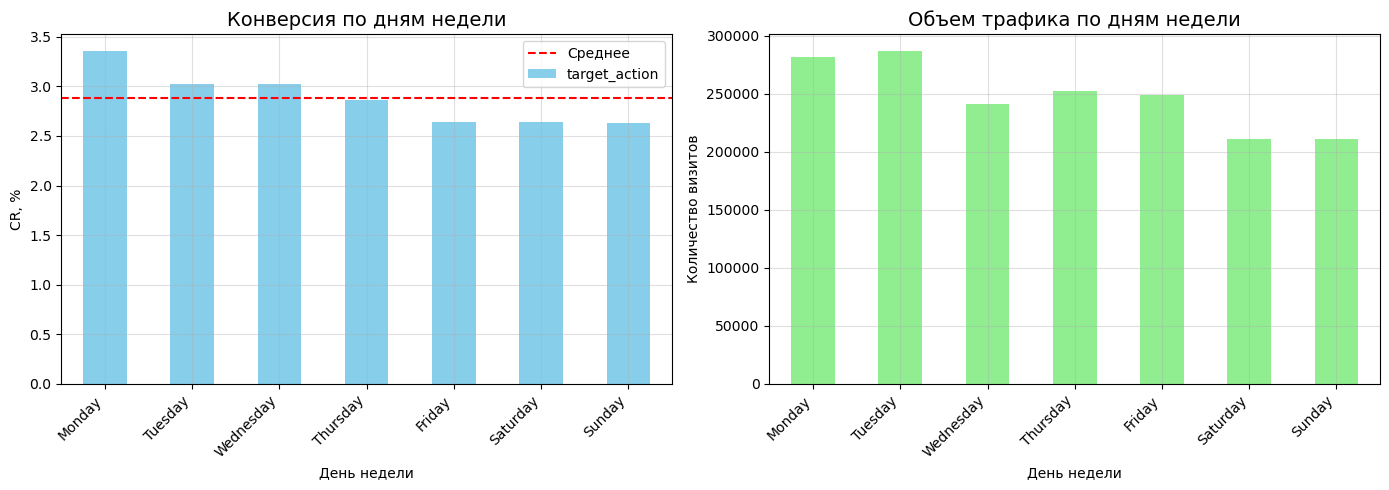

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Конверсия по дням недели
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_cr = df.groupby('day_of_week')['target_action'].mean().reindex(weekday_order) * 100

weekday_cr.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Конверсия по дням недели', fontsize=14)
axes[0].set_xlabel('День недели')
axes[0].set_ylabel('CR, %')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].axhline(y=weekday_cr.mean(), color='red', linestyle='--', label='Среднее')
axes[0].grid(alpha=0.4)
axes[0].legend()

# Объем трафика по дням недели
weekday_visits = df['day_of_week'].value_counts().reindex(weekday_order)

weekday_visits.plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Объем трафика по дням недели', fontsize=14)
axes[1].set_xlabel('День недели')
axes[1].set_ylabel('Количество визитов')
axes[1].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.show()

### 10.2. Визуализация по месяцам

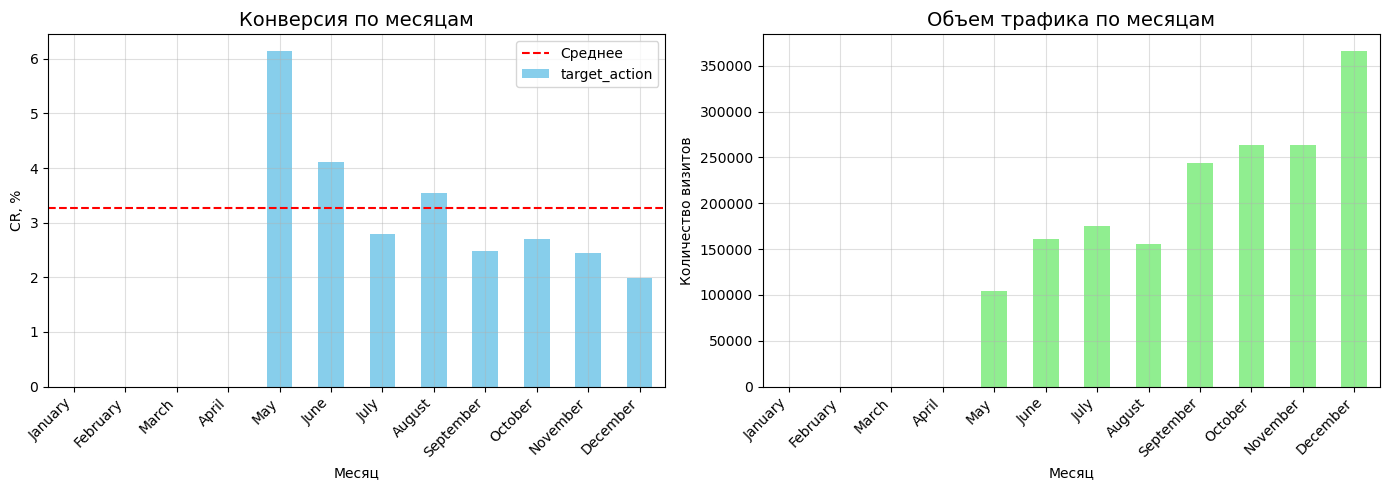

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Конверсия по месяцам
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 
               'August', 'September', 'October', 'November', 'December']
month_cr = df.groupby('month')['target_action'].mean().reindex(month_order) * 100

month_cr.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Конверсия по месяцам', fontsize=14)
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('CR, %')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].axhline(y=month_cr.mean(), color='red', linestyle='--', label='Среднее')
axes[0].grid(alpha=0.4)
axes[0].legend()

# Объем трафика по месяцам
month_visits = df['month'].value_counts().reindex(month_order)

month_visits.plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Объем трафика по месяцам', fontsize=14)
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Количество визитов')
axes[1].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.show()

### 10.3. Визуализация эффективности соцсетей

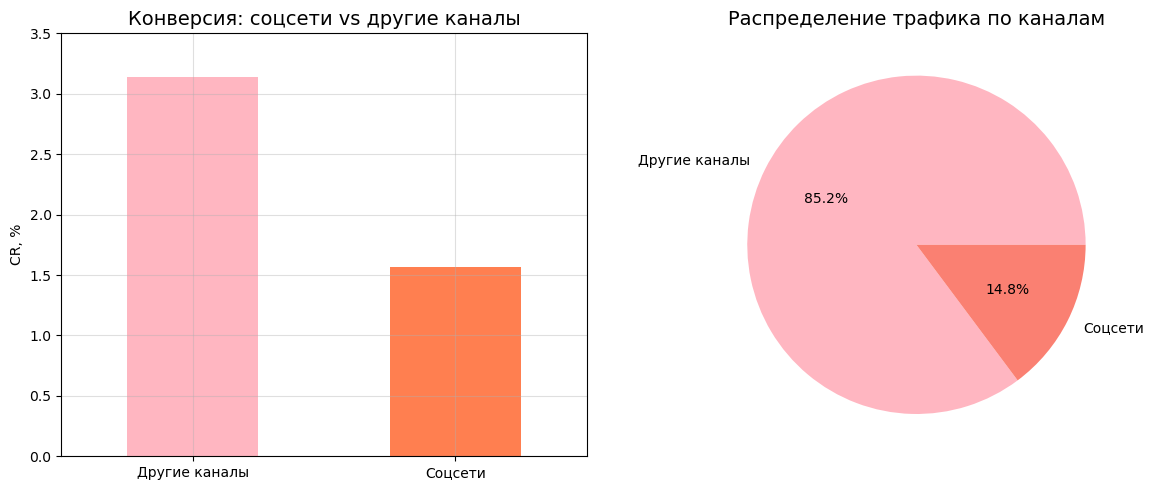

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Сравнение конверсии
social_cr = df.groupby('ad_in_social_media')['target_action'].mean() * 100
social_cr.index = ['Другие каналы', 'Соцсети']

social_cr.plot(kind='bar', ax=axes[0], color=['lightpink', 'coral'])
axes[0].set_title('Конверсия: соцсети vs другие каналы', fontsize=14)
axes[0].set_ylabel('CR, %')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].set_ylim(0, 3.5)
axes[0].grid(alpha=0.4)

# Распределение трафика
social_traffic = df['ad_in_social_media'].value_counts()
social_traffic.index = ['Другие каналы', 'Соцсети']

social_traffic.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['lightpink', 'salmon'])
axes[1].set_title('Распределение трафика по каналам', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 10.4. Визуализация по устройствам

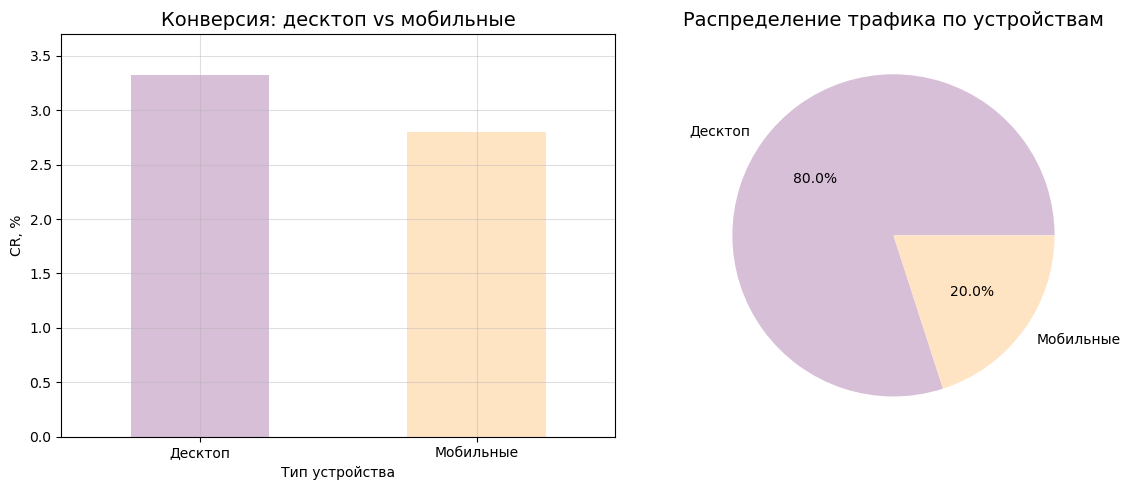

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Сравнение конверсии
device_cr = df.groupby('device_category')['target_action'].mean() * 100
device_cr.index = ['Десктоп', 'Мобильные']

device_cr.plot(kind='bar', ax=axes[0], color=['thistle', 'bisque'])
axes[0].set_title('Конверсия: десктоп vs мобильные', fontsize=14)
axes[0].set_xlabel('Тип устройства')
axes[0].set_ylabel('CR, %')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].set_ylim(0, 3.7)
axes[0].grid(alpha=0.4)

# Распределение трафика
device_traffic = df['device_category'].value_counts()
device_traffic.index = ['Десктоп', 'Мобильные']

device_traffic.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['thistle', 'bisque'])
axes[1].set_title('Распределение трафика по устройствам', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# 11. Итоговые выводы

1. Гипотезы:
   - Органический трафик показывает статистически значимо БОЛЬШУЮ конверсию, чем платный
   - Мобильные и десктопные устройства НЕ имеют статистически значимого отличия по конверсии
   - Города присутствия НЕ имеют статистически значимого отличия от других регионов по конверсии


2. Самый целевой трафик по CR:
   - Бренды устройств: Samsung, OPPO, Vivo, Apple
   - Браузеры: Mozilla Firefox, Microsoft Edge, Yandex Browser
   - Локация: Татарстан, Краснодарский Край, Чечня, Москва, Башкортостан
   - Автопроизводитель: volkswagen, toyota, kia, lada-vaz, skoda
   - Модель машины: toyota camri, volkswagen polo, kia rio, kia seltos, skoda rapid (бюджетные автомобили)
   - Время просмотра: первая половина недели / начало рабочей недели
   
   
3. Самый целевой трафик по общему объёму:
    - Бренды устройств: Apple, Sumsung, Xiaomi, Huawei
    - Браузеры: Chrome, Safari, Yandex Browser
    - Локация: Москва, Санкт-Петербург, Московская Область, Краснодарский Край, Свердловская Область
    - Автопроизводитель: skoda, volkswagen, mercedes-benz, lada-vaz
    - Модель машины: skoda rapid, volkswagen polo, lada-vaz vesta (бюджетные автомобили)
    - Время просмотра: первая половина недели / начало рабочей недели


4. Соцсети:
    - трафик из социальных сетей имеет статистически меньшую CR, чем с других источников


5. Рекомендации:
   - Инвестировать в органический трафик (SEO, контент-маркетинг)
   - Не увеличивать бюджет на рекламу в соцсетях (эффективность ниже, чем с других источников)
   - Продвигать бюджетные модели: Toyota Camry, Volkswagen Polo, Kia Rio.
   - Усилить рекламную активность в начале недели